### Seaborn
Seaborn is a plotting library for statistical analysis it is written on matplotlib

In [2]:
# !pip install seaborn

In [3]:
import seaborn

In [4]:
seaborn.__version__

'0.13.2'

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
import numpy as np
import pandas as pd

In [9]:
df = pd.DataFrame(
    {
        'Months':np.arange(1,13),
        'Sales':np.random.randint(10000,100000,12)
    }
)

In [14]:
df

,Months,Sales
0,1,43198
1,2,31191
2,3,41739
3,4,22118
4,5,820863
5,6,63980
6,7,20116
7,8,55506
8,9,50152
9,10,47536


In [15]:
df.Sales.mean()

np.float64(107730.33333333333)

In [16]:
df.describe()

,Months,Sales
count,12.000000,12.000000
mean,6.500000,107730.333333
std,3.605551,225407.229935
min,1.000000,14425.000000
25%,3.750000,28922.750000
50%,6.500000,45367.000000
75%,9.250000,57624.500000
max,12.000000,820863.000000


<Axes: xlabel='Sales', ylabel='Count'>

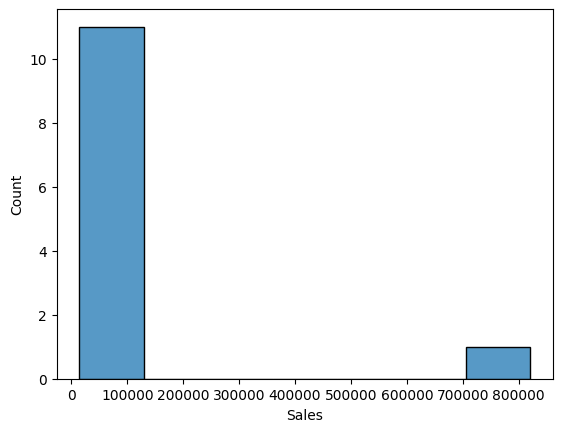

In [29]:
sns.histplot( df['Sales'] )

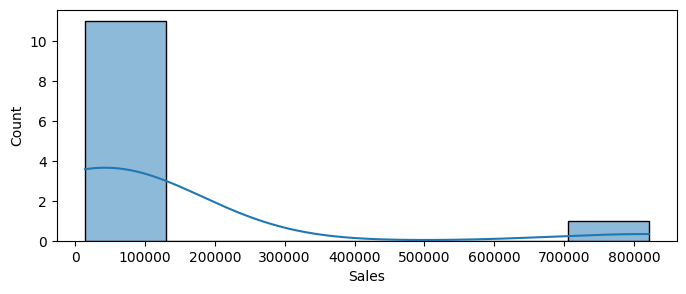

In [31]:
plt.figure(figsize=(8,3))
sns.histplot( df['Sales'] , kde=True )
plt.show()

C:\Users\Croma Campus\AppData\Local\Temp\ipykernel_14528\3578619496.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df['Sales'] )


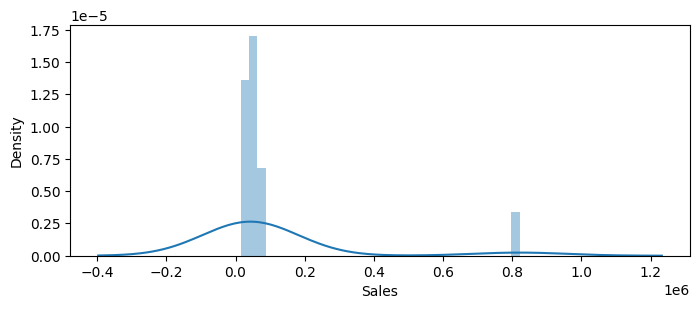

In [32]:
plt.figure(figsize=(8,3))
sns.distplot( df['Sales'] )
plt.show()

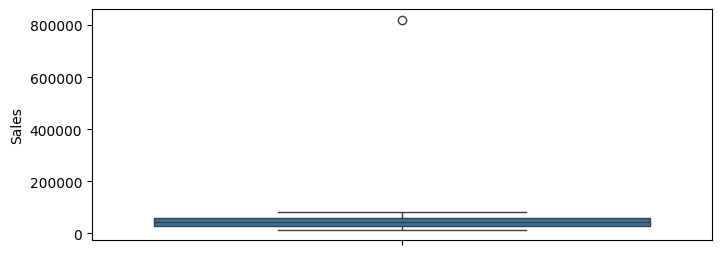

In [33]:
plt.figure(figsize=(8,3))
sns.boxplot( df['Sales'] )
plt.show()

In [34]:
# Outlier Removal
# IQR , Z-Score etc
# IQR : Interquantile Range

In [35]:
# IQR = Q3 - Q1
# min_val = Q1 - 1.5*IQR
# max_val = Q3 + 1.5*IQR

In [36]:
Q3 = df['Sales'].quantile(0.75)
Q1 = df['Sales'].quantile(0.25)
IQR = Q3 - Q1
min_val = Q1 - 1.5*IQR
max_val = Q3 + 1.5*IQR
Q1 , Q3 , IQR , min_val , max_val

(np.float64(28922.75),
 np.float64(57624.5),
 np.float64(28701.75),
 np.float64(-14129.875),
 np.float64(100677.125))

In [37]:
newdf = df[df['Sales']<max_val]

In [38]:
newdf

,Months,Sales
0,1,43198
1,2,31191
2,3,41739
3,4,22118
5,6,63980
6,7,20116
7,8,55506
8,9,50152
9,10,47536
10,11,81940


C:\Users\Croma Campus\AppData\Local\Temp\ipykernel_14528\1740543756.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( newdf['Sales'] )


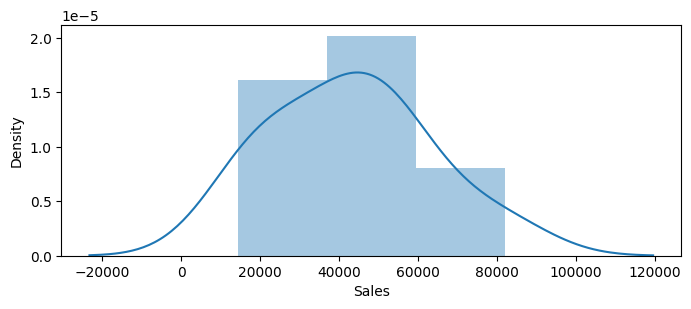

In [39]:
plt.figure(figsize=(8,3))
sns.distplot( newdf['Sales'] )
plt.show()

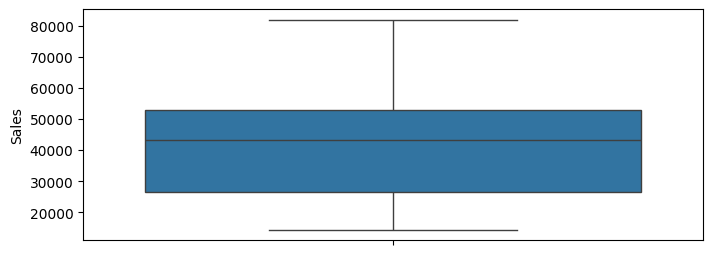

In [40]:
plt.figure(figsize=(8,3))
sns.boxplot( newdf['Sales'] )
plt.show()

In [41]:
outlier = df[df.Sales>max_val]

In [42]:
outlier

,Months,Sales
4,5,820863


In [43]:
df.Sales.sum()

np.int64(1292764)

In [44]:
newdf.mean()

Months        6.636364
Sales     42900.090909
dtype: float64

In [45]:
# Z_Score

In [46]:
df['z_score'] = (df['Sales']-df['Sales'].mean())/df['Sales'].std()

In [47]:
df

,Months,Sales,z_score
0,1,43198,-0.286292
1,2,31191,-0.339560
2,3,41739,-0.292765
3,4,22118,-0.379812
4,5,820863,3.163752
5,6,63980,-0.194095
6,7,20116,-0.388694
7,8,55506,-0.231689
8,9,50152,-0.255441
9,10,47536,-0.267047


In [49]:
newdf2 = df[df['z_score']<3]

In [50]:
newdf2

,Months,Sales,z_score
0,1,43198,-0.286292
1,2,31191,-0.339560
2,3,41739,-0.292765
3,4,22118,-0.379812
5,6,63980,-0.194095
6,7,20116,-0.388694
7,8,55506,-0.231689
8,9,50152,-0.255441
9,10,47536,-0.267047
10,11,81940,-0.114417


In [54]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [56]:
df = sns.load_dataset('titanic')

In [57]:
df.shape

(891, 15)

In [58]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [59]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

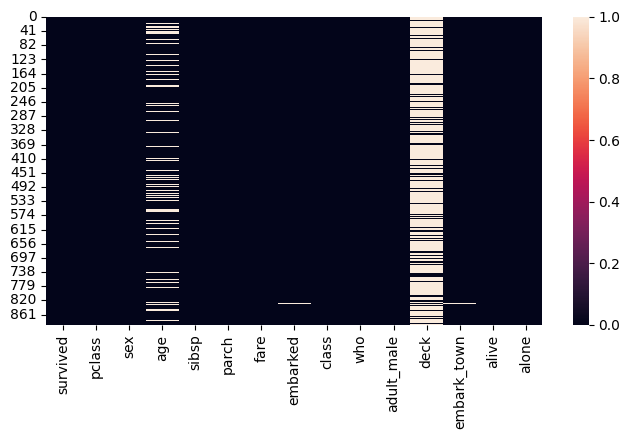

In [60]:
plt.figure(figsize=(8,4))
sns.heatmap( df.isnull() )
plt.show()

In [61]:
df = df.drop(columns=['deck'])

In [63]:
df = df.ffill() 

In [65]:
df.isnull().sum().sum()

np.int64(0)

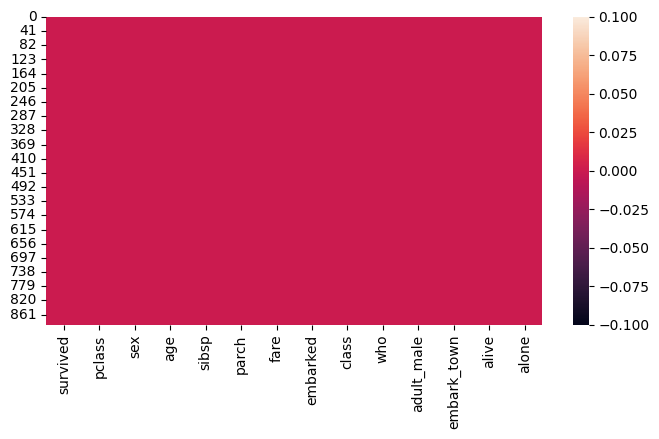

In [66]:
plt.figure(figsize=(8,4))
sns.heatmap( df.isnull() )
plt.show()

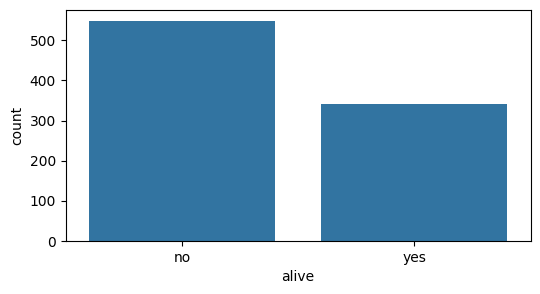

In [68]:
plt.figure(figsize=(6,3))
sns.countplot( x='alive' , data=df)
plt.show()

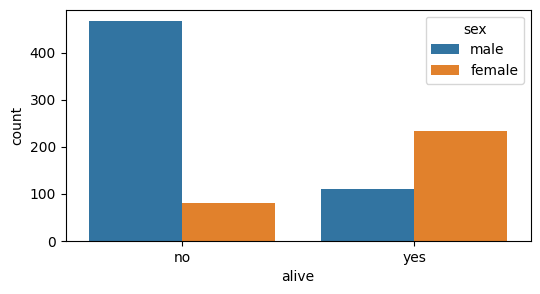

In [69]:
plt.figure(figsize=(6,3))
sns.countplot( x='alive' , hue='sex' , data=df)
plt.show()

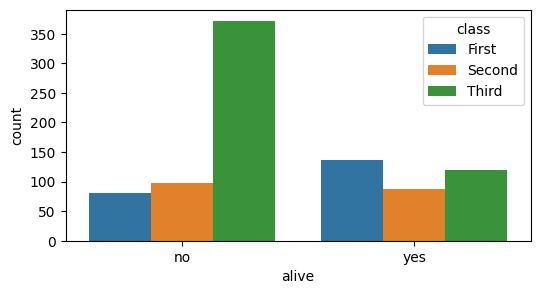

In [70]:
plt.figure(figsize=(6,3))
sns.countplot( x='alive' , hue='class' , data=df)
plt.show()